<a href="https://colab.research.google.com/github/smiritisi-msc26-lgtm/BPTA/blob/main/vertex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

m(Edges)  | Vertex Cover Size   | Running Time (seconds)   
------------------------------------------------------------
10        | 5                   | 0.00021868               
15        | 5                   | 0.00039957               
20        | 6                   | 0.00038979               
25        | 6                   | 0.00036827               
30        | 7                   | 0.00055436               
35        | 7                   | 0.00053087               
40        | 8                   | 0.00058538               
45        | 9                   | 0.00140386               


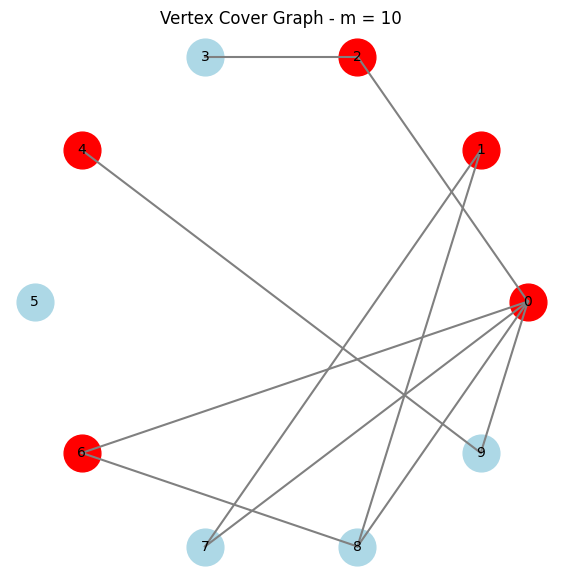

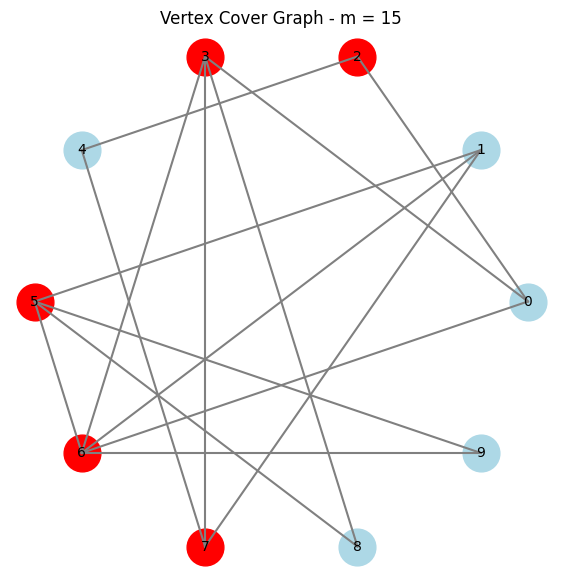

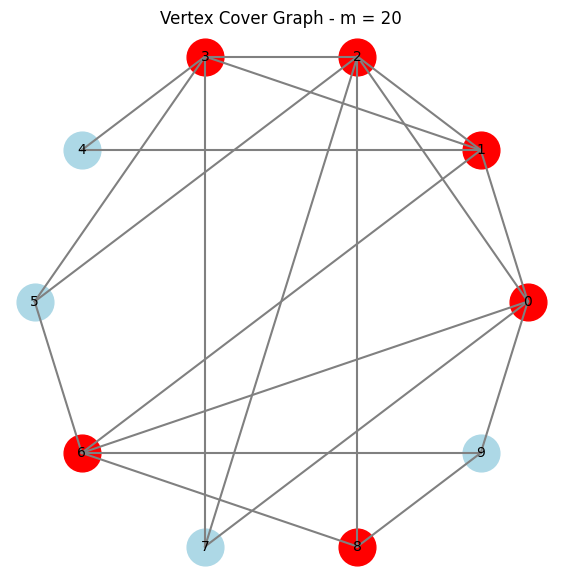

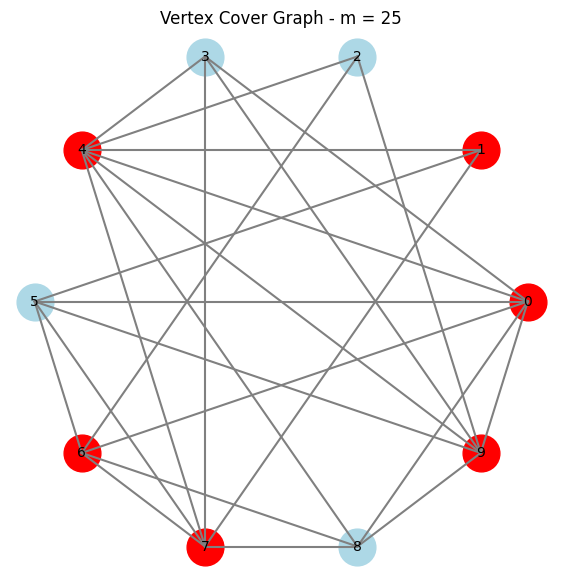

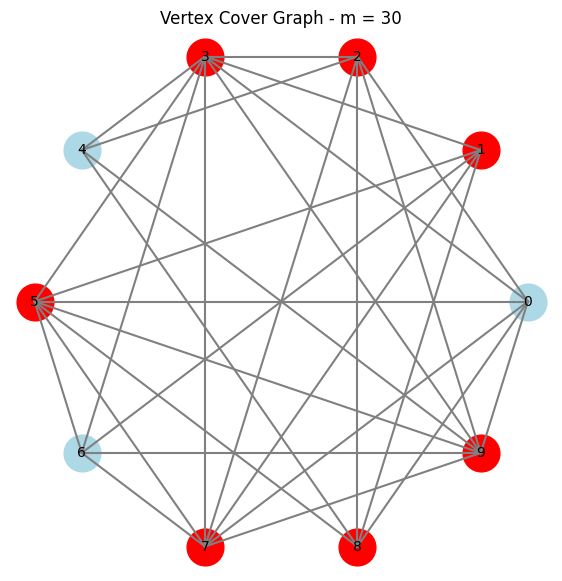

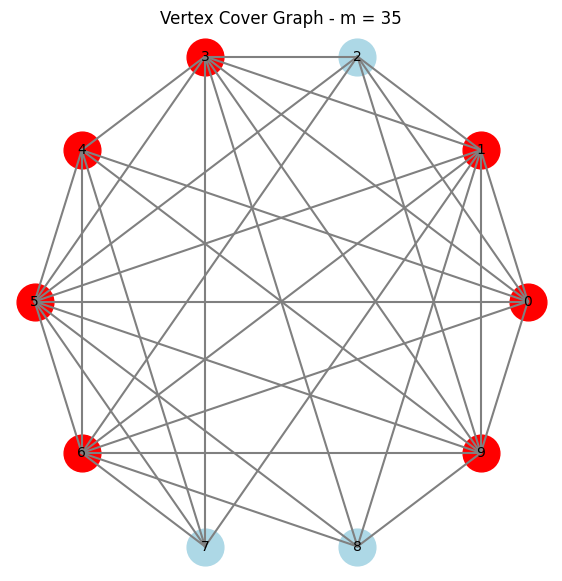

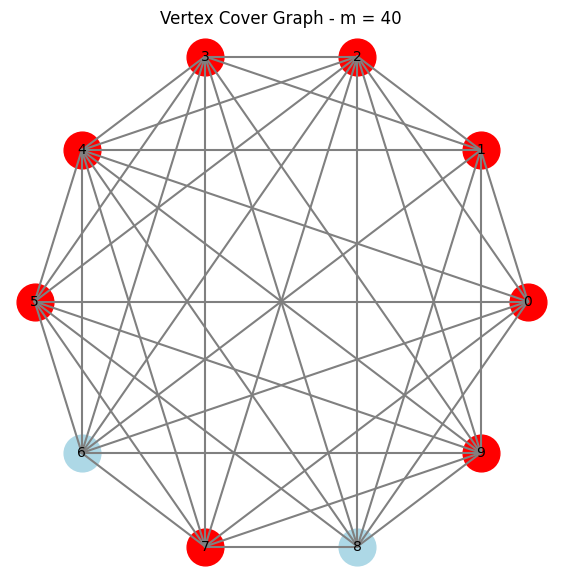

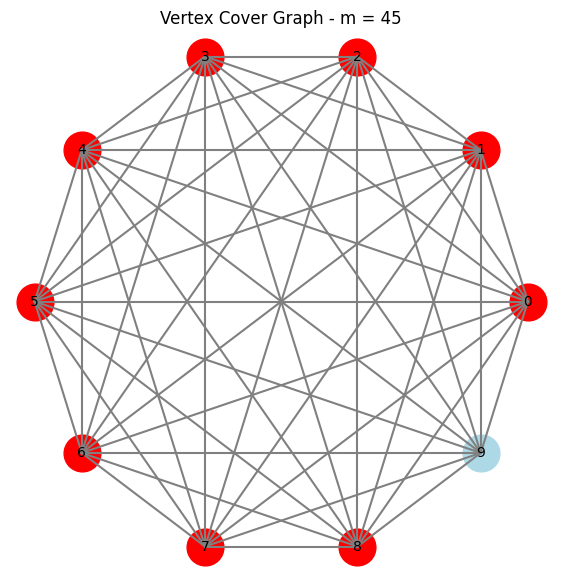

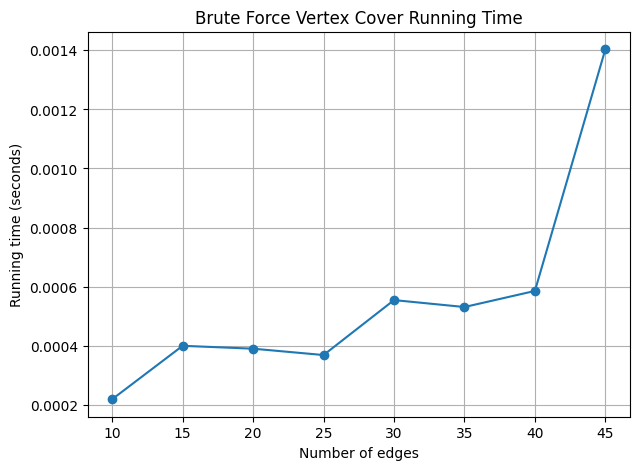

In [ ]:
import time
import random
import itertools
import json
import math
import matplotlib.pyplot as plt


def is_vertex_cover(edges, subset):
    for u, v in edges:
        if u not in subset and v not in subset:
            return False
    return True


def find_min_vertex_cover(n, edges):
    for k in range(n + 1):
        for subset in itertools.combinations(range(n), k):
            if is_vertex_cover(edges, subset):
                return k, subset


def generate_random_graph(n, m):
    all_possible_edges = list(itertools.combinations(range(n), 2))
    return random.sample(all_possible_edges, m)


n = 10
m_values = [10, 15, 20, 25, 30, 35, 40, 45]

datasets = []
results = []

random.seed(42)

print(f"{'m(Edges)':<10}| {'Vertex Cover Size':<20}| {'Running Time (seconds)':<25}")
print("-" * 60)

for m in m_values:

    edges = generate_random_graph(n, m)

    start_time = time.perf_counter()

    vertex_cover = find_min_vertex_cover(n, edges)

    end_time = time.perf_counter()

    running_time = end_time - start_time

    print(
        f"{m:<10}| {vertex_cover[0]:<20}| {running_time:<25.8f}"
    )

    datasets.append({
        "n": n,
        "m": m,
        "edges": edges
    })

    results.append({
        "n": n,
        "m": m,
        "vertex_cover_size": vertex_cover[0],
        "running_time": running_time
    })


with open("vertex_cover_datasets.json", "w") as file:
    json.dump(datasets, file, indent=4)


for dataset in datasets:

    m = dataset["m"]
    edges = [tuple(edge) for edge in dataset["edges"]]

    vertex_cover = find_min_vertex_cover(n, edges)[1]

    positions = {}

    for i in range(n):
        angle = 2 * math.pi * i / n
        x = 5 * math.cos(angle)
        y = 5 * math.sin(angle)
        positions[i] = (x, y)

    plt.figure(figsize=(7, 7))

    for u, v in edges:

        x1, y1 = positions[u]
        x2, y2 = positions[v]

        plt.plot(
            [x1, x2],
            [y1, y2],
            color="gray"
        )

    for vertex in range(n):

        x, y = positions[vertex]

        if vertex in vertex_cover:
            plt.scatter(
                x, y,
                s=700,
                color="red"
            )
        else:
            plt.scatter(
                x, y,
                s=700,
                color="lightblue"
            )

        plt.text(
            x,
            y,
            str(vertex),
            ha="center",
            va="center"
        )

    plt.title("Vertex Cover Graph - m = " + str(m))
    plt.axis("off")
    plt.show()


running_times = []

for result in results:
    running_times.append(result["running_time"])


plt.figure(figsize=(7, 5))

plt.plot(
    m_values,
    running_times,
    marker="o"
)

plt.xlabel("Number of edges")
plt.ylabel("Running time (seconds)")
plt.title("Brute Force Vertex Cover Running Time")
plt.grid()

plt.show()